In [1]:
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten
from tensorflow.keras.datasets import mnist

## Abstract interface for all classifiers

In [2]:
class MnistClassifierInterface(ABC):

    @abstractmethod
    def train(self, train_images, train_labels):
        pass

    @abstractmethod
    def predict(self, test_images):
        pass

## Random Forest implementation

In [3]:
class RFClassifier(MnistClassifierInterface):
    # Random Forest with 100 trees
    def __init__(self):
        self.model = RandomForestClassifier(n_estimators=100)

     # Flatten images from (28,28) to (784,)
    def train(self, train_images, train_labels):
        n_samples = train_images.shape[0]
        train_images = train_images.reshape(n_samples, -1)
        self.model.fit(train_images, train_labels)

    def predict(self, test_images):
        n_samples = test_images.shape[0]
        test_images = test_images.reshape(n_samples, -1)
        return self.model.predict(test_images)

## Feed-Forward Neural Network implementation

In [4]:
class FFNNClassifier(MnistClassifierInterface):
  def __init__(self):
    self.model = keras.Sequential(
    [keras.layers.Flatten(input_shape = (28, 28)), # flatten image
    Dense(128, activation = 'relu'), # hidden layer
    Dense(64, activation = 'relu'), # hidden layer
    Dense(10, activation = 'softmax')]) # output layer with 10 classes

    # Compile model with optimizer and loss function
    self.model.compile(optimizer = 'adam', loss= 'sparse_categorical_crossentropy', metrics = ['accuracy'])

  def train(self, train_images, train_labels):
    self.model.fit(train_images, train_labels, epochs=20)

  def predict(self, test_images):
    # Predict probabilities and convert to class labels
    probs = self.model.predict(test_images)
    return np.argmax(probs, axis=1)


## Convolutional Neural Network implementation

In [5]:
class CNNClassifier(MnistClassifierInterface):
  def __init__(self):
    # CNN architecture
    self.model = keras.Sequential(
        [Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
         MaxPooling2D((2, 2)),
         Conv2D(64, (3,3), activation='relu'),
         MaxPooling2D(pool_size=(2,2)),
         Conv2D(64, (3, 3), activation='relu'),
         Flatten(),
         Dense(64, activation='relu'),
         Dense(10, activation='softmax')])

    self.model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

  def train(self, train_images, train_labels):
    # Reshape images to include channel dimension
    train_images = train_images.reshape(-1,28,28,1)
    self.model.fit(train_images, train_labels, epochs=10, batch_size=500)

  def predict(self, test_images):
    test_images = test_images.reshape(-1,28,28,1)
    probs = self.model.predict(test_images)
    return np.argmax(probs, axis=1)


## Class that selects algorithm

In [6]:
class MnistClassifier:
    def __init__(self, algorithm: str):
        self.algorithms = {
            'rf': RFClassifier(),
            'nn': FFNNClassifier(),
            'cnn': CNNClassifier()
        }
        if algorithm not in self.algorithms:
            raise ValueError("Unknown algorithm")

        self.model = self.algorithms[algorithm]

    def train(self, x_train, y_train):
        self.model.train(x_train, y_train)

    def predict(self, x_test):
        return self.model.predict(x_test)

## Visualize misclassified examples

In [7]:
def plot_errors(test_images, test_labels, predictions):
  num_classes = 10
  samples_per_class = 7
  test_predicted_np = np.array(predictions)
  fig, axs = plt.subplots(samples_per_class, num_classes, figsize=(10.0, 8.0))

  for i in range(num_classes):
      idxs = np.flatnonzero((test_labels == i) & (test_predicted_np != i))

      for j in range(min(samples_per_class, len(idxs))):
          idx = idxs[j]
          axs[j, i].imshow(test_images[idx], cmap='gray')
          axs[j, i].set_title(f"{test_labels[idx]}, {test_predicted_np[idx]}")
          axs[j, i].axis('off')
  plt.setp(axs,xticks=[],yticks=[])
  plt.show()

In [8]:
(images, labels),(_, _) = mnist.load_data()

# Normalize images to [0,1]
images = images / 255


train_images = images[:50000]
train_labels = labels[:50000]

test_images = images[50000:60000]
test_labels = labels[50000:60000]


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
classifier = MnistClassifier("cnn")
classifier.train(train_images, train_labels)
predictions_cnn = classifier.predict(test_images)
accuracy = np.mean(predictions_cnn == test_labels)

print("Accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 39s 369ms/step - accuracy: 0.8311 - loss: 0.5831
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 373ms/step - accuracy: 0.9629 - loss: 0.1198
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 36s 365ms/step - accuracy: 0.9762 - loss: 0.0787
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 369ms/step - accuracy: 0.9826 - loss: 0.0553
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 42s 375ms/step - accuracy: 0.9852 - loss: 0.0474
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 378ms/step - accuracy: 0.9878 - loss: 0.0396
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 367ms/step - accuracy: 0.9893 - loss: 0.0356
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 368ms/step - accuracy: 0.9902 - loss: 0.0302
Epoch 9/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 37s 365ms/step - accuracy: 0.9910 - loss: 0.0294
Epoch 10/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 35s 351ms/step - accuracy: 0.9928 - loss: 0.0231
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
Accuracy: 0.9886


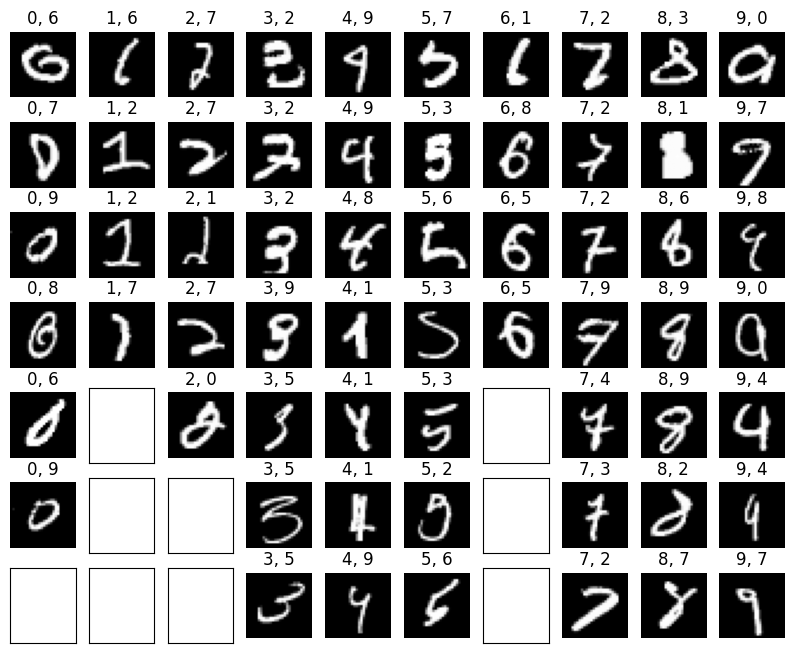

In [10]:
plot_errors(test_images, test_labels, predictions_cnn)

In [11]:
classifier = MnistClassifier("rf")
classifier.train(train_images, train_labels)
predictions_rf = classifier.predict(test_images)
accuracy = np.mean(predictions_rf == test_labels)

print("Accuracy:", accuracy)

Accuracy: 0.9719


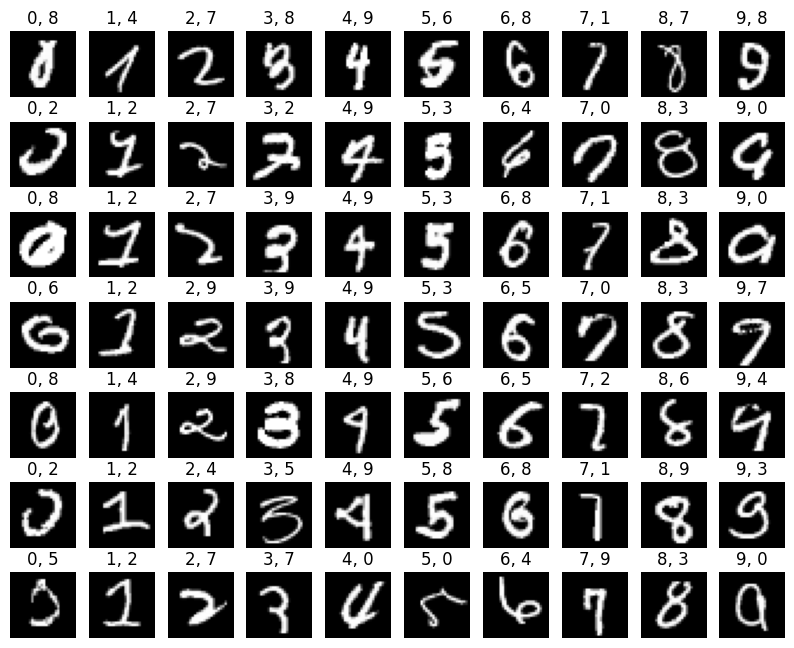

In [12]:
plot_errors(test_images, test_labels, predictions_rf)

In [13]:
classifier = MnistClassifier("nn")
classifier.train(train_images, train_labels)
predictions_nn = classifier.predict(test_images)
accuracy = np.mean(predictions_nn == test_labels)

print("Accuracy:", accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9235 - loss: 0.2625
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9665 - loss: 0.1124
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9759 - loss: 0.0787
Epoch 4/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9816 - loss: 0.0585
Epoch 5/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9853 - loss: 0.0454
Epoch 6/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9879 - loss: 0.0371
Epoch 7/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9902 - loss: 0.0305
Epoch 8/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9910 - loss: 0.0264
Epoch 9/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9928 - loss: 0.0206
Epoch 10/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9931 - loss: 0.0201
Epoch 11/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9941 - loss: 0.0177
Epoch 12/20
1563/1563 ━━━━━━━━

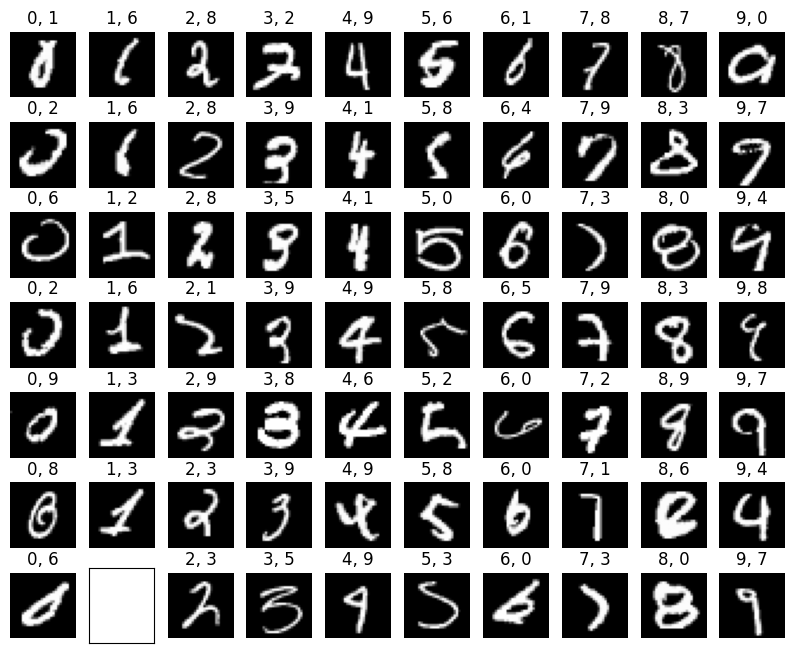

In [14]:
plot_errors(test_images, test_labels, predictions_nn)